<a href="https://colab.research.google.com/github/Madhuanabala/breast-cancer/blob/model-validations/pickel_random_forest_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

In [8]:
df=pd.read_csv('/content/combined_dataset_fs_2.csv')
df

,Unnamed: 0,KRFP17,KRFP1146,KRFP1157,KRFP2667,KRFP2986,KRFP3058,KRFP3180,KRFP3360,KRFP3395,...,BCUT2D_CHGHI_1.0,BCUT2D_CHGLO_1.0,BCUT2D_MRHI_2.0,Chi4n_0,PEOE_VSA6_0,SlogP_VSA11_0,RingCount_0,fr_NH0_0,fr_aniline_0,fr_aryl_methyl_0
0,0,1,0,1,1,1,1,0,1,1,...,1,0,0,0,0,0,0,1,1,1
1,1,1,1,1,1,1,1,0,1,1,...,1,0,0,0,0,0,0,1,1,1
2,2,1,0,1,1,1,1,0,1,1,...,1,0,0,0,0,0,0,1,1,1
3,3,0,0,0,0,1,0,0,0,0,...,1,1,0,1,1,1,1,1,1,1
4,4,0,0,0,0,1,0,0,0,0,...,1,1,0,1,0,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1812,1812,0,0,0,0,1,1,0,0,0,...,1,0,0,1,1,1,0,1,1,1
1813,1813,0,0,0,0,1,1,0,0,0,...,1,0,0,1,1,1,0,1,1,1
1814,1814,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,1,0,1,1
1815,1815,0,1,0,0,0,0,1,0,0,...,1,0,0,1,1,1,1,1,0,1


In [9]:
np.random.seed(42)
random.seed(42)

In [10]:
df = df.drop('Unnamed: 0', axis=1)
X = df.drop(["bioactivity_class"], axis=1)
Y = df["bioactivity_class"]

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=42)

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [13]:
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

In [14]:
accuracy = accuracy_score(Y_test, y_pred)
auc_score = roc_auc_score(Y_test, y_pred_proba)
clf_report = classification_report(Y_test, y_pred, output_dict=True)

In [15]:
print("Random Forest Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print(f"Classification Report:\n{classification_report(Y_test, y_pred)}")

Random Forest Evaluation Metrics:
Accuracy: 0.8864
AUC: 0.9543
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       249
           1       0.91      0.88      0.89       297

    accuracy                           0.89       546
   macro avg       0.89      0.89      0.89       546
weighted avg       0.89      0.89      0.89       546



In [16]:

from sklearn.metrics import confusion_matrix, mean_absolute_error, cohen_kappa_score
conf_matrix = confusion_matrix(Y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[222  27]
 [ 35 262]]


In [17]:
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 0] + conf_matrix[1, 1])
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
# Mean Absolute Error (MAE)
mae = mean_absolute_error(Y_test, y_pred)
print(f"\nMean Absolute Error (MAE): {mae:.4f}")
# Cohen's Kappa Score
kappa = cohen_kappa_score(Y_test, y_pred)
print(f"\nCohen's Kappa Score: {kappa:.4f}")


Sensitivity (Recall): 0.8822

Mean Absolute Error (MAE): 0.1136

Cohen's Kappa Score: 0.7717


In [18]:
fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

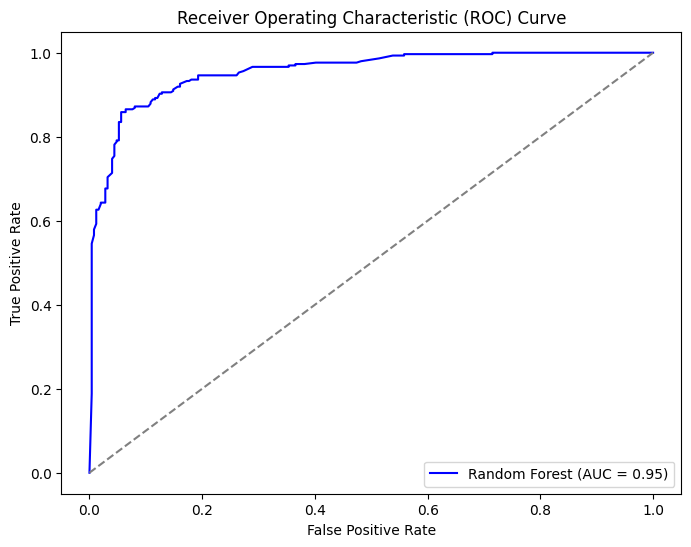

In [19]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

cross validations

In [21]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, Y, cv=10, scoring='accuracy')
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores)} ± {np.std(cv_scores)}")

Cross-validation accuracy scores: [0.5989011  0.7032967  0.56043956 0.63736264 0.58241758 0.54945055
 0.62087912 0.79558011 0.85082873 0.7679558 ]
Mean Accuracy: 0.666711189363123 ± 0.10089831114031828


In [22]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, Y, cv=skf, scoring='accuracy')

print(f"Stratified K-Fold Accuracy: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores)} ± {np.std(cv_scores)}")

Stratified K-Fold Accuracy: [0.90659341 0.88461538 0.91208791 0.8956044  0.89010989 0.9010989
 0.8956044  0.87845304 0.90055249 0.9281768 ]
Mean Accuracy: 0.8992896606156273 ± 0.013481113919392712


In [24]:
import pickle

# Save model
with open("extratrees_model.pkl", "wb") as model_file:
    pickle.dump(rf, model_file)

# Load model
with open("extratrees_model.pkl", "rb") as model_file:
    loaded_model = pickle.load(model_file)

# Test loaded model
y_pred_loaded = loaded_model.predict(X_test)
print(f"Loaded Model Accuracy: {accuracy_score(Y_test, y_pred_loaded)}")


Loaded Model Accuracy: 0.8864468864468864


In [25]:
import pandas as pd

# Load unknown data
unknown_df = pd.read_excel("/content/combined unkknown.xlsx")

In [26]:
# Get the feature names used during training
training_features = loaded_model.feature_names_in_

# Select only the necessary columns from unknown_df, and reorder them
unknown_df = unknown_df.reindex(columns=training_features)

In [27]:
# Predict class labels
predictions = loaded_model.predict(unknown_df)

# Predict probabilities (if needed)
probabilities = loaded_model.predict_proba(unknown_df)

original_unknown_df = pd.read_excel("/content/combined unkknown.xlsx")
IMPPAT_ids = original_unknown_df["IMPPAT_id"]

# Convert predictions to a DataFrame
predictions_df = pd.DataFrame({
    "IMPPAT_id": IMPPAT_ids,
    "Predicted_Class": predictions,
    "Probability_Class_0": probabilities[:, 0],  # Probability of class 0
    "Probability_Class_1": probabilities[:, 1]   # Probability of class 1
})

# Save predictions
predictions_df.to_csv("random forest predictions.csv", index=False)
print("Predictions saved to random forest predictions.csv")

Predictions saved to random forest predictions.csv


In [29]:
df_check = pd.read_csv("random forest predictions.csv")
print(df_check.head())  # Check if the order looks correct

       IMPPAT_id  Predicted_Class  Probability_Class_0  Probability_Class_1
0  Â IMPHY005665                1                0.485                0.515
1    IMPHY004660                1                0.410                0.590
2    IMPHY012021                0                0.660                0.340
3    IMPHY011844                0                0.525                0.475
4    IMPHY004978                1                0.415                0.585


Predicted Class Distribution

<ipython-input-30-d807a18e40cd>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=predictions_df["Predicted_Class"], palette="magma")


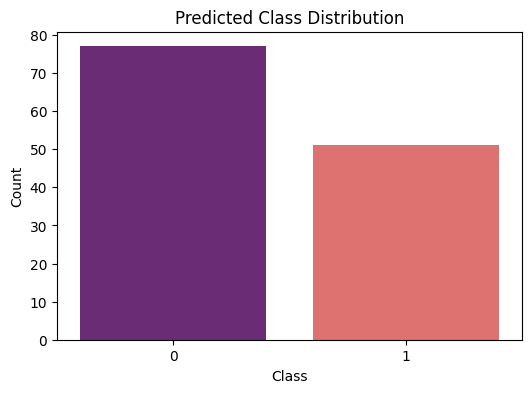

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count occurrences of each class
plt.figure(figsize=(6, 4))
sns.countplot(x=predictions_df["Predicted_Class"], palette="magma")

plt.title("Predicted Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Prediction Probability Distribution

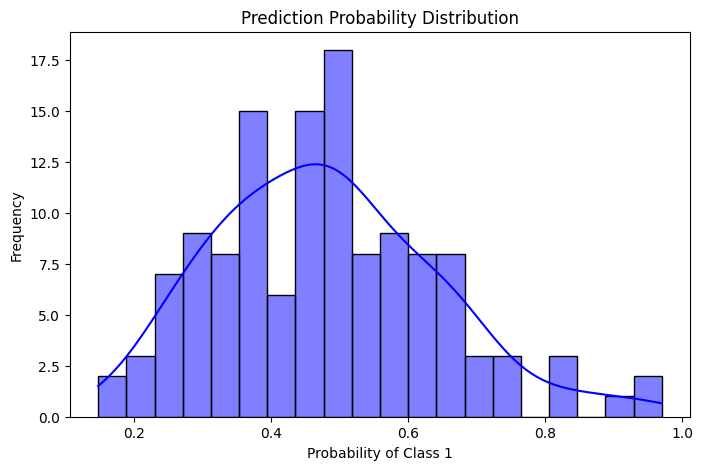

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(predictions_df["Probability_Class_1"], bins=20, kde=True, color="blue")

plt.title("Prediction Probability Distribution")
plt.xlabel("Probability of Class 1")
plt.ylabel("Frequency")
plt.show()